<a href="https://colab.research.google.com/github/mercury0925/2026-1_CV/blob/main/CV_HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW#2-1

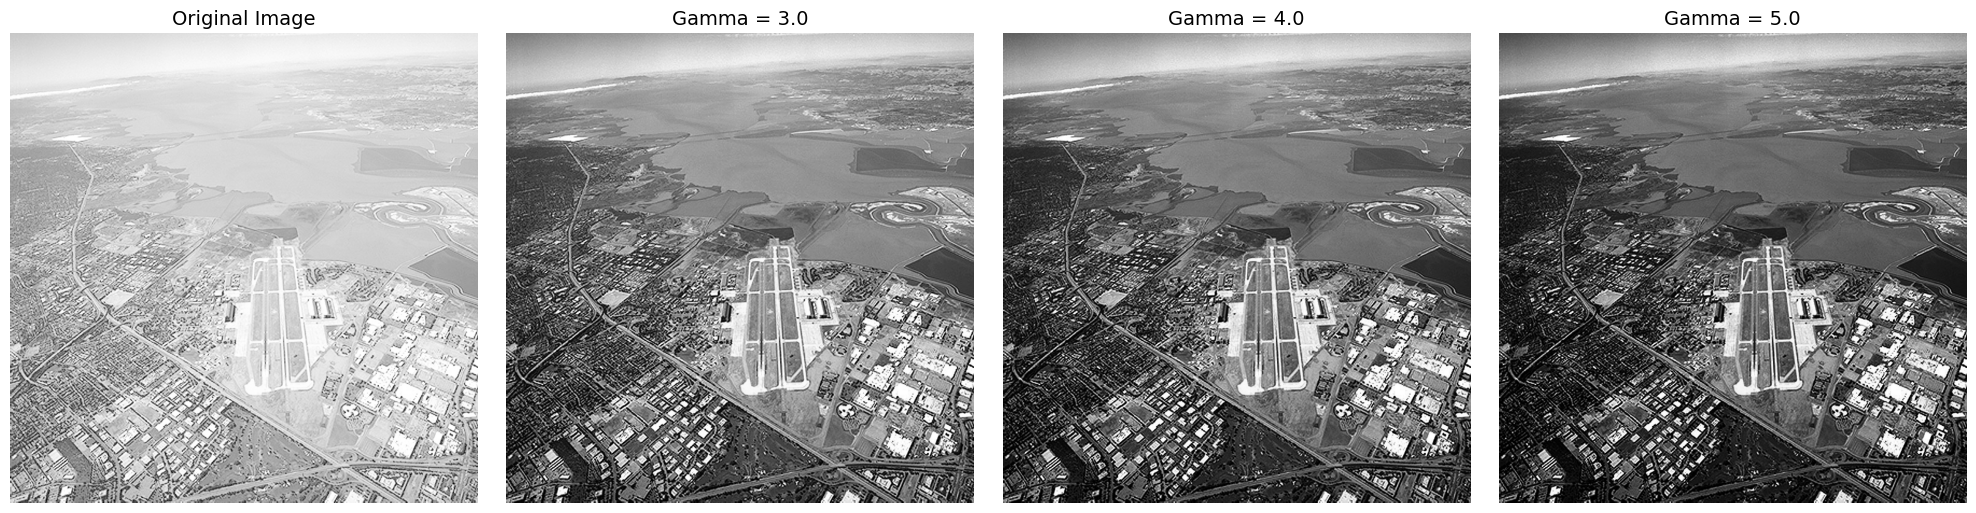

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests

# 1. 실험 영상 다운로드
url = "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0309(a)(washed_out_aerial_image).tif"
resp = requests.get(url)
image_array = np.asarray(bytearray(resp.content), dtype="uint8")
img = cv2.imdecode(image_array, cv2.IMREAD_GRAYSCALE)

# 2. 영상 정규화 (0 ~ 1 사이의 값으로 변환)
img_normalized = img / 255.0

# 3. 감마 변환 함수 정의
def apply_gamma(normalized_img, gamma):
    # s = c * r^gamma (여기서 c는 L-1, 즉 255)
    result = 255.0 * (normalized_img ** gamma)
    # 계산된 값을 0~255 사이로 제한하고 uint8 타입으로 변환
    return np.clip(result, 0, 255).astype(np.uint8)

# 4. 감마 값(3.0, 4.0, 5.0)에 따른 결과 생성
gamma_3 = apply_gamma(img_normalized, 3.0)
gamma_4 = apply_gamma(img_normalized, 4.0)
gamma_5 = apply_gamma(img_normalized, 5.0)

# 5. 결과 시각화
titles = ['Original Image', 'Gamma = 3.0', 'Gamma = 4.0', 'Gamma = 5.0']
images = [img, gamma_3, gamma_4, gamma_5]

plt.figure(figsize=(20, 5))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i], fontsize=14)
    plt.axis('off')
plt.tight_layout()
plt.show()

#### HW#2-1 결과 분석

* **$\gamma = 3.0$**: 전체적인 톤다운 효과로 뭉개졌던 도로와 건물의 윤곽이 나타나기 시작
* **$\gamma = 4.0$**: 명암 대비가 최적으로 확장되어 구조물의 디테일이 가장 선명하고 자연스럽게 식별됨
* **$\gamma = 5.0$**: 영상이 과하게 어두워져 일부 픽셀이 뭉개지고 형태 정보 손실이 발생

**결론**
빛이 바랜(Washed-out) 영상에 1보다 큰 감마 연산을 적용하면 전체 밝기는 낮아지고 명암 대비는 넓혀져 숨겨진 디테일이 복원됨. 실험 결과 $\gamma = 4.0$이 최적의 파라미터임.

# HW#2-2

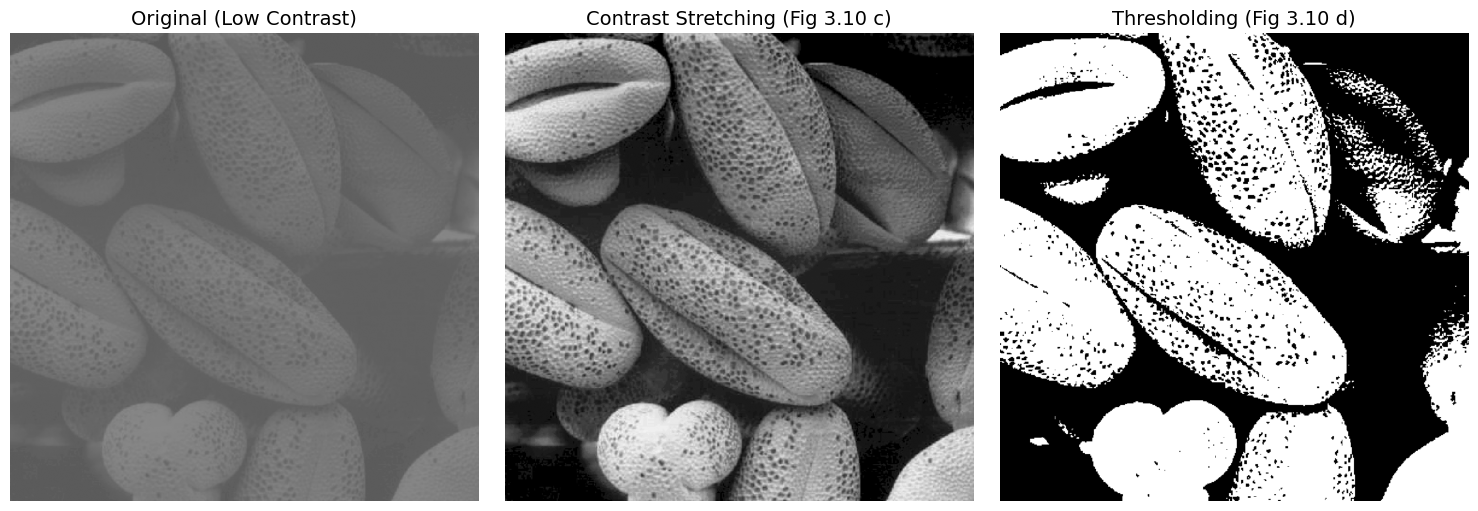

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests

# 1. 실험 영상 다운로드
url = "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0310(b)(washed_out_pollen_image).tif"
resp = requests.get(url)
image_array = np.asarray(bytearray(resp.content), dtype="uint8")
img = cv2.imdecode(image_array, cv2.IMREAD_GRAYSCALE)

# 2. 명암 대비 확장 (Contrast Stretching)
# 영상 내 존재하는 픽셀의 최소값을 0으로, 최대값을 255로 선형 변환하여 범위를 확장
# 수식: s = (r - r_min) / (r_max - r_min) * 255
img_stretched = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)

# 3. 이진화 (Thresholding)
# 명암 대비가 확장된 영상에 Otsu 알고리즘을 적용하여 자동으로 최적의 임계값(Threshold)을 찾음
# 픽셀 값이 임계값보다 크면 255(흰색), 작으면 0(검은색)으로 변환
_, img_thresh = cv2.threshold(img_stretched, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 4. 결과 시각화
titles = ['Original (Low Contrast)', 'Contrast Stretching (Fig 3.10 c)', 'Thresholding (Fig 3.10 d)']
images = [img, img_stretched, img_thresh]

plt.figure(figsize=(15, 5))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(images[i], cmap='gray', vmin=0, vmax=255)
    plt.title(titles[i], fontsize=14)
    plt.axis('off')
plt.tight_layout()
plt.show()

#### HW#2-2 결과 분석

* **명암 대비 확장 (Contrast Stretching)**: 좁은 범위에 뭉쳐있던 픽셀 값들이 0~255 범위 전체로 넓어지면서 회색으로 뭉개져 안 보이던 꽃가루 표면의 돌기와 형태가 뚜렷하게 살아남.
* **이진화 (Thresholding)**: 픽셀이 흑(0)과 백(255) 두 가지 색상으로만 극단적으로 나뉘어 입체감은 사라졌지만, 타겟 객체(꽃가루)와 배경이 완벽하게 분리됨.

**결론**
저대비 영상은 명암 대비를 확장하여 형태를 우선적으로 뚜렷하게 만든 후 이진화를 수행해야 객체와 배경을 가장 깔끔하게 분할(Segmentation)할 수 있음.

# HW#2-3

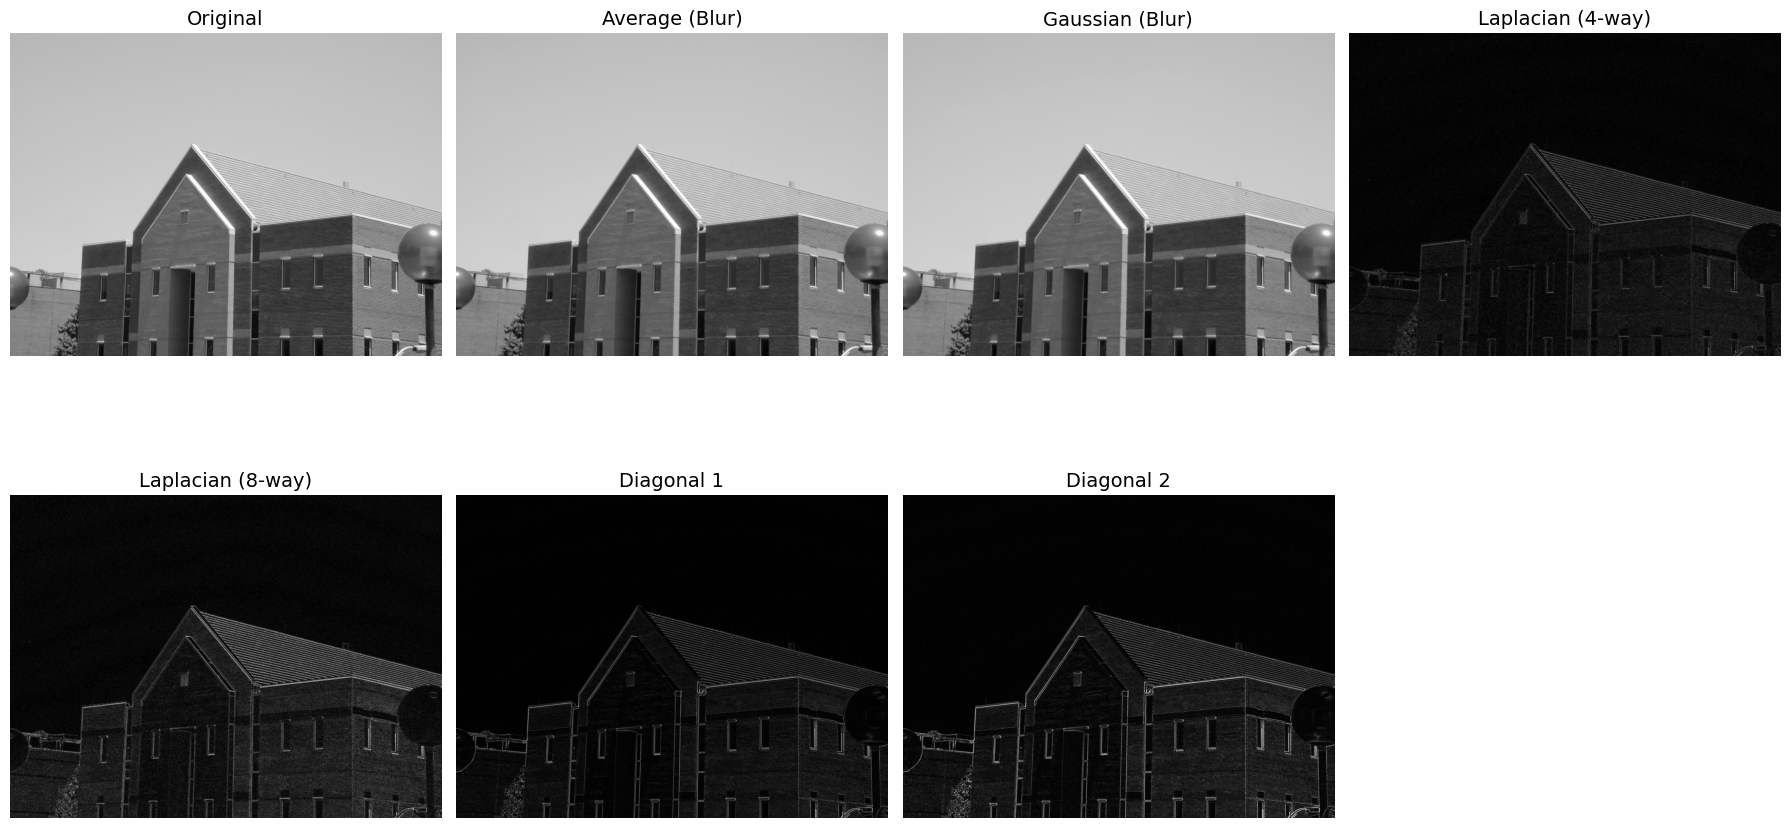

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests

# 1. 임의의 영상 다운로드
url = "https://raw.githubusercontent.com/kjcheoi-class/CV/main/school.jpg"
resp = requests.get(url)
image_array = np.asarray(bytearray(resp.content), dtype="uint8")
img = cv2.imdecode(image_array, cv2.IMREAD_GRAYSCALE)

# 2. 강의 자료에 제시된 6가지 마스크 정의
# (1) 3x3 Average Filter (평균 필터)
mask1_avg = np.ones((3, 3), np.float32) / 9.0

# (2) 5x5 Gaussian Filter (가우시안 필터)
mask2_gauss = np.array([
    [0.0030, 0.0133, 0.0219, 0.0133, 0.0030],
    [0.0133, 0.0596, 0.0983, 0.0596, 0.0133],
    [0.0219, 0.0983, 0.1621, 0.0983, 0.0219],
    [0.0133, 0.0596, 0.0983, 0.0596, 0.0133],
    [0.0030, 0.0133, 0.0219, 0.0133, 0.0030]
], dtype=np.float32)

# (3) 3x3 Laplacian Filter 1 (상하좌우 4방향)
mask3_lap1 = np.array([
    [0, -1, 0],
    [-1, 4, -1],
    [0, -1, 0]
], dtype=np.float32)

# (4) 3x3 Laplacian Filter 2 (대각선 포함 8방향)
mask4_lap2 = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.float32)

# (5) 3x3 Diagonal Filter 1 (대각선 에지)
mask5_diag1 = np.array([
    [-1, 0, 0],
    [ 0, 0, 0],
    [ 0, 0, 1]
], dtype=np.float32)

# (6) 3x3 Diagonal Filter 2 (대각선 에지 / 엠보싱)
mask6_diag2 = np.array([
    [-1, -1, 0],
    [-1,  0, 1],
    [ 0,  1, 1]
], dtype=np.float32)


# 3. 컨볼루션 연산 적용 (cv2.filter2D 사용)
res1 = cv2.filter2D(img, -1, mask1_avg)
res2 = cv2.filter2D(img, -1, mask2_gauss)

res3 = cv2.convertScaleAbs(cv2.filter2D(img, cv2.CV_64F, mask3_lap1))
res4 = cv2.convertScaleAbs(cv2.filter2D(img, cv2.CV_64F, mask4_lap2))
res5 = cv2.convertScaleAbs(cv2.filter2D(img, cv2.CV_64F, mask5_diag1))
res6 = cv2.convertScaleAbs(cv2.filter2D(img, cv2.CV_64F, mask6_diag2))

# 4. 결과 시각화
titles = ['Original', 'Average (Blur)', 'Gaussian (Blur)',
          'Laplacian (4-way)', 'Laplacian (8-way)', 'Diagonal 1', 'Diagonal 2']
images = [img, res1, res2, res3, res4, res5, res6]

plt.figure(figsize=(18, 10))
for i in range(7):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i], fontsize=14)
    plt.axis('off')
plt.tight_layout()
plt.show()

#### HW#2-3 결과 분석

* **Average (Blur)**: 영상이 전체적으로 흐려지며(Blur) 객체의 경계선이 부드럽게 뭉개짐.
* **Gaussian (Blur)**: 평균 필터보다 자연스럽게 노이즈를 줄이며 디테일을 상대적으로 더 잘 보존함.
* **Laplacian (4-way)**: 밝기가 급변하는 건물의 윤곽선(에지) 등 윤곽만 얇고 밝게 추출됨.
* **Laplacian (8-way)**: 대각선 변화까지 감지하여 4방향 라플라시안보다 에지가 훨씬 더 강하고 뚜렷하게 검출됨.
* **Diagonal 1**: 특정 대각선 방향의 경계만 추출되어 얕은 입체감(엠보싱 효과)이 나타남.
* **Diagonal 2**: 대각선 1보다 경계와 질감을 강하게 표현하여 입체감이 극대화됨.

**결론**
마스크(커널)의 가중치 분포에 따라 영상을 부드럽게 만들거나(스무딩), 윤곽선을 날카롭게 강조하거나(샤프닝), 특정 방향의 입체감을 부여(엠보싱)하는 등 시각적 특징을 선택적으로 추출할 수 있음.

# HW#2-4

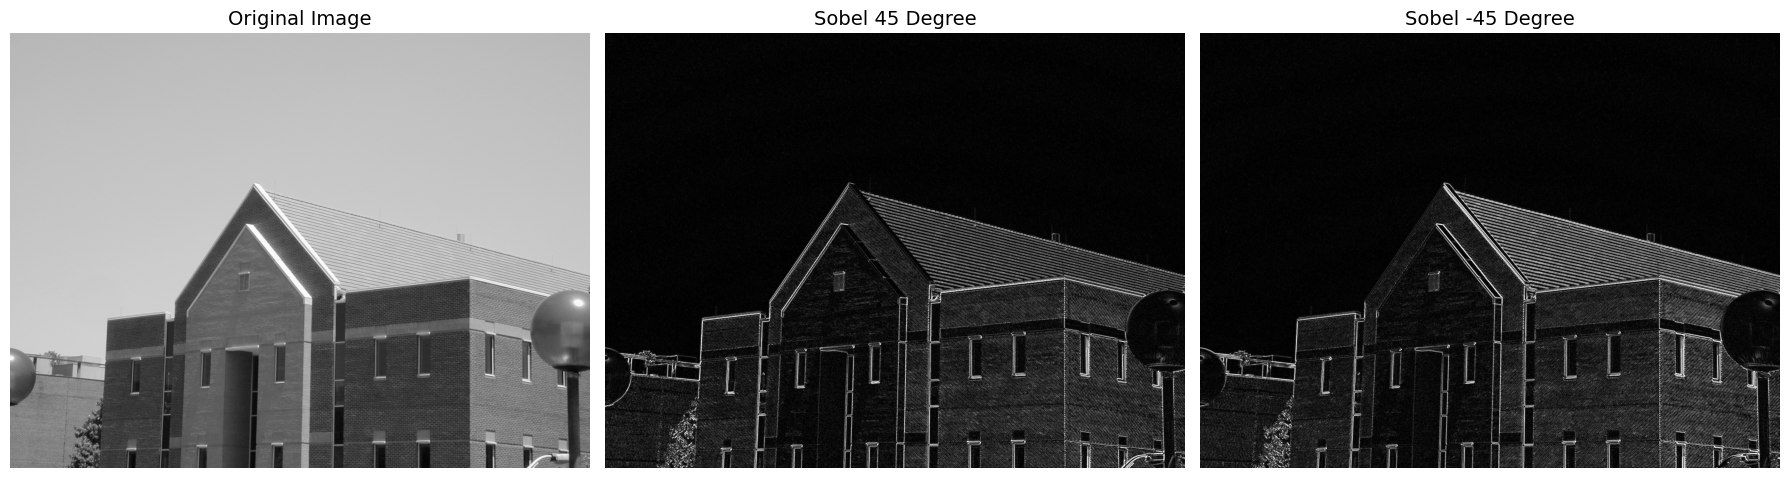

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests

# 1. 실험 영상 다운로드
url = "https://raw.githubusercontent.com/kjcheoi-class/CV/main/school.jpg"
resp = requests.get(url)
image_array = np.asarray(bytearray(resp.content), dtype="uint8")
img = cv2.imdecode(image_array, cv2.IMREAD_GRAYSCALE)

# 2. 대각선 방향 Sobel 마스크 설계
# 45도 방향 (좌하단 -> 우상단 방향의 에지 검출)
sobel_45 = np.array([
    [-2, -1,  0],
    [-1,  0,  1],
    [ 0,  1,  2]
], dtype=np.float32)

# -45도 방향 (좌상단 -> 우하단 방향의 에지 검출)
sobel_minus_45 = np.array([
    [ 0,  1,  2],
    [-1,  0,  1],
    [-2, -1,  0]
], dtype=np.float32)

# 3. 컨볼루션 연산 적용
# 미분 값이 음수가 되는 것을 방지하기 위해 64비트 실수형(cv2.CV_64F)으로 먼저 계산
res_45 = cv2.filter2D(img, cv2.CV_64F, sobel_45)
res_minus_45 = cv2.filter2D(img, cv2.CV_64F, sobel_minus_45)

# 계산된 결과에 절대값을 취하고 다시 uint8(0~255) 형태로 변환하여 시각화 준비
res_45_abs = cv2.convertScaleAbs(res_45)
res_minus_45_abs = cv2.convertScaleAbs(res_minus_45)

# 4. 결과 시각화
titles = ['Original Image', 'Sobel 45 Degree', 'Sobel -45 Degree']
images = [img, res_45_abs, res_minus_45_abs]

plt.figure(figsize=(18, 6))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i], fontsize=14)
    plt.axis('off')
plt.tight_layout()
plt.show()

#### HW#2-4

* **Sobel 45 Degree**: 건물의 지붕이나 그림자 등 전체 구조물 중 좌하단에서 우상단 방향으로 기울어진 사선 형태의 윤곽선만 밝고 뚜렷하게 추출됨.
* **Sobel -45 Degree**: 반대로 좌상단에서 우하단 방향으로 기울어진 사선 윤곽선만 선택적으로 강조되며, 반대 방향의 선들은 어둡게 억제됨.

**결론**
기본 수평/수직 에지 검출을 넘어 마스크의 가중치를 대각선으로 배치함으로써, 특정 각도로 기울어진 객체의 경계선만 독립적으로 분리하고 식별할 수 있음.

# HW#2-5

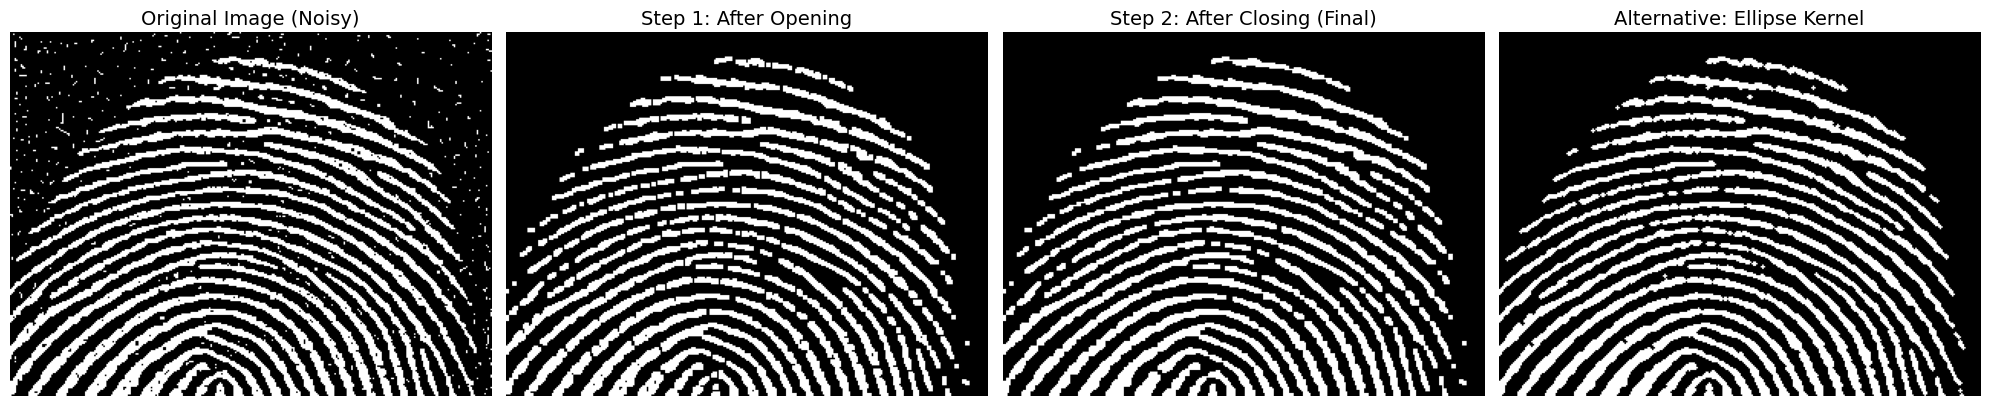

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests

# 1. 실험 영상 다운로드
url = "https://raw.githubusercontent.com/kjcheoi-class/CV/main/finger.jpg"
resp = requests.get(url)
image_array = np.asarray(bytearray(resp.content), dtype="uint8")
img = cv2.imdecode(image_array, cv2.IMREAD_GRAYSCALE)

# 2. 확실한 이진화를 위해 Threshold 적용
_, img_bin = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# 3. 구조 요소(Structuring Element) 생성
# 3x3 크기의 정사각형 마스크를 사용
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

# 4. 모폴로지 연산 적용
# 1단계: 열기(Opening) 연산 -> 배경의 자잘한 흰색 잡음 제거
img_opened = cv2.morphologyEx(img_bin, cv2.MORPH_OPEN, kernel)

# 2단계: 닫기(Closing) 연산 -> 지문 선 내부의 검은색 잡음 제거 및 끊어진 선 연결
img_closed = cv2.morphologyEx(img_opened, cv2.MORPH_CLOSE, kernel)

# 더 좋은 방법을 찾기 위한 추가 실험: 타원형(Ellipse) 커널 사용
kernel_ellipse = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
img_opened_ell = cv2.morphologyEx(img_bin, cv2.MORPH_OPEN, kernel_ellipse)
img_closed_ell = cv2.morphologyEx(img_opened_ell, cv2.MORPH_CLOSE, kernel_ellipse)

# 5. 결과 시각화
titles = ['Original Image (Noisy)', 'Step 1: After Opening', 'Step 2: After Closing (Final)', 'Alternative: Ellipse Kernel']
images = [img_bin, img_opened, img_closed, img_closed_ell]

plt.figure(figsize=(20, 5))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i], fontsize=14)
    plt.axis('off')
plt.tight_layout()
plt.show()

#### HW#2-5 결과 분석

**1. 기본 방법 적용 (정사각형 커널 `MORPH_RECT`)**
* **열기(Opening)**: 배경에 흩뿌려진 자잘한 흰색 점잡음(Salt Noise)을 효과적으로 제거
* **닫기(Closing)**: 지문 선 내부에 파인 검은 구멍을 메우고 끊어져 있던 지문의 융기선들을 하나로 연결

**2. 더 좋은 방법 적용 (타원형 커널 `MORPH_ELLIPSE`)**
* 지문은 둥근 곡선 형태가 주를 이루기 때문에 정사각형 커널을 사용하면 선의 가장자리가 블록처럼 각지고 투박해지는 현상 발생
* 이를 개선하기 위해 타원형(Ellipse) 구조 요소를 적용한 결과 잡음 제거 및 선 연결 효과는 완벽히 유지하면서 지문 특유의 자연스럽고 부드러운 곡선 형태가 훨씬 원형에 가깝게 보존됨을 확인

**결론**
복합적인 잡음이 섞인 지문 영상은 '열기 후 닫기' 연산을 통해 깨끗하게 복원할 수 있으며 이때 타겟 객체의 기하학적 특성(곡선)에 맞춰 원형 또는 타원형 구조 요소를 선택하는 것이 화질 개선에 더욱 효과적임.

# HW#2-6

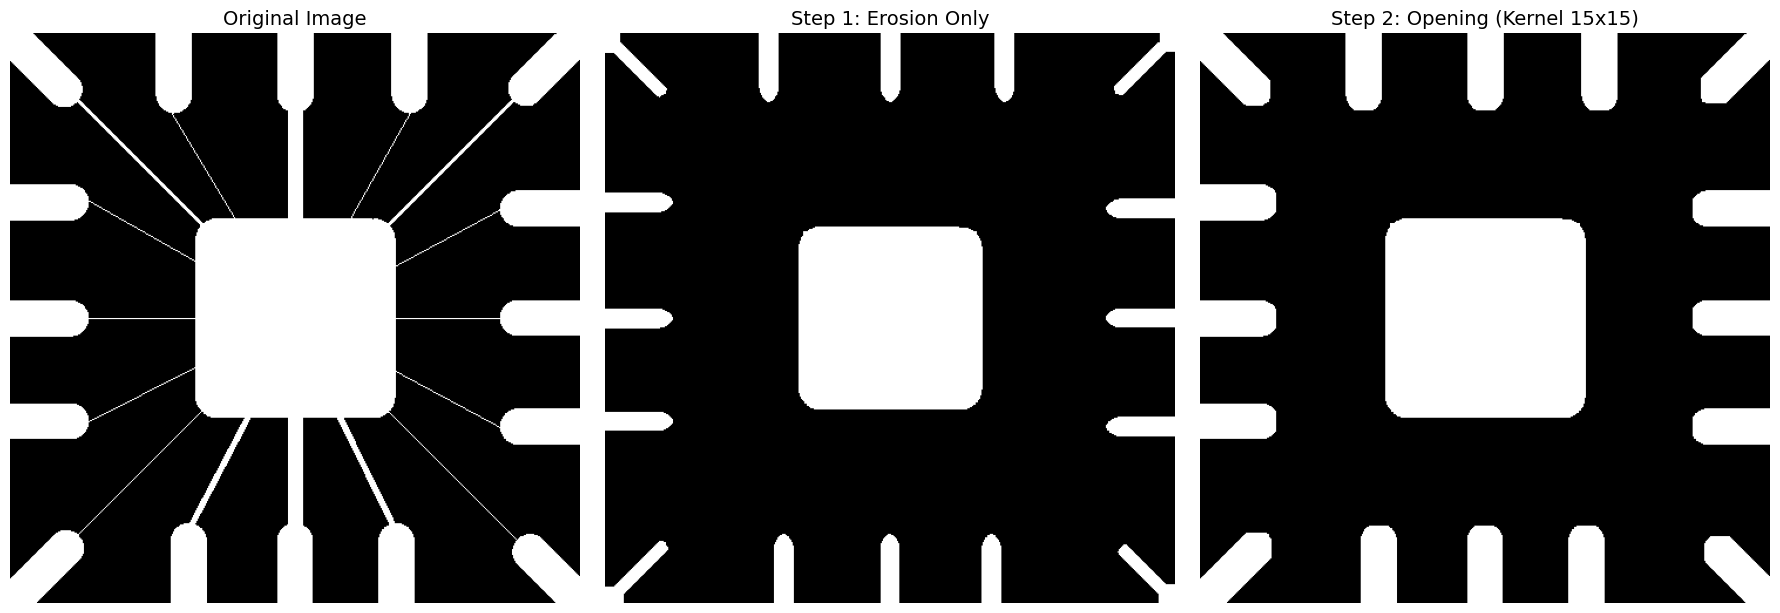

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests

# 1. 실험 영상 다운로드
url = "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0905(a)(wirebond-mask).tif"
resp = requests.get(url)
image_array = np.asarray(bytearray(resp.content), dtype="uint8")
img = cv2.imdecode(image_array, cv2.IMREAD_GRAYSCALE)

# 2. 이진화 확인
_, img_bin = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# 3. 구조 요소(Structuring Element) 설계
kernel_size = 15
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_size, kernel_size))

# 4. 열기(Opening) 연산 적용 (침식 후 팽창)
img_opened = cv2.morphologyEx(img_bin, cv2.MORPH_OPEN, kernel)

# 중간 단계인 침식(Erosion) 연산만 적용해보기
img_eroded = cv2.erode(img_bin, kernel)

# 5. 결과 시각화
titles = ['Original Image', 'Step 1: Erosion Only', f'Step 2: Opening (Kernel {kernel_size}x{kernel_size})']
images = [img_bin, img_eroded, img_opened]

plt.figure(figsize=(18, 6))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i], fontsize=14)
    plt.axis('off')
plt.tight_layout()
plt.show()

#### HW#2-6 결과 분석

**1. 구조 요소(Structuring Element) 설계 원리**
* 없애고자 하는 얇은 선(Wire)의 두께보다는 크고 남기고자 하는 객체(칩, 패드)보다는 작은 크기(15x15)의 사각형 마스크를 설정함

**2. 단계별 연산 결과 분석**
* **1단계: 침식(Erosion)**: 15x15 마스크를 통과시키면 마스크 크기보다 얇은 선분들은 완전히 깎여나가 소멸됨. 반면, 면적이 넓은 중앙 칩과 가장자리 패드들은 테두리만 일부 깎인 채 살아남음.
* **2단계: 팽창(Dilation)을 포함한 열기(Opening)**: 침식된 영상에 다시 팽창을 수행하여 칩과 패드를 원래 크기로 복구함. 이때 1단계에서 완전히 지워진 선분들은 복원될 기준점(Seed)이 없으므로 영구적으로 제거됨.

**결론**
타겟의 기하학적 크기를 고려하여 구조 요소를 설계한 뒤 열기(Opening) 연산을 적용하면, 영상 내에서 특정 굵기 이하의 객체(선분)만 선택적으로 완벽하게 지울 수 있음.

# HW#2-7

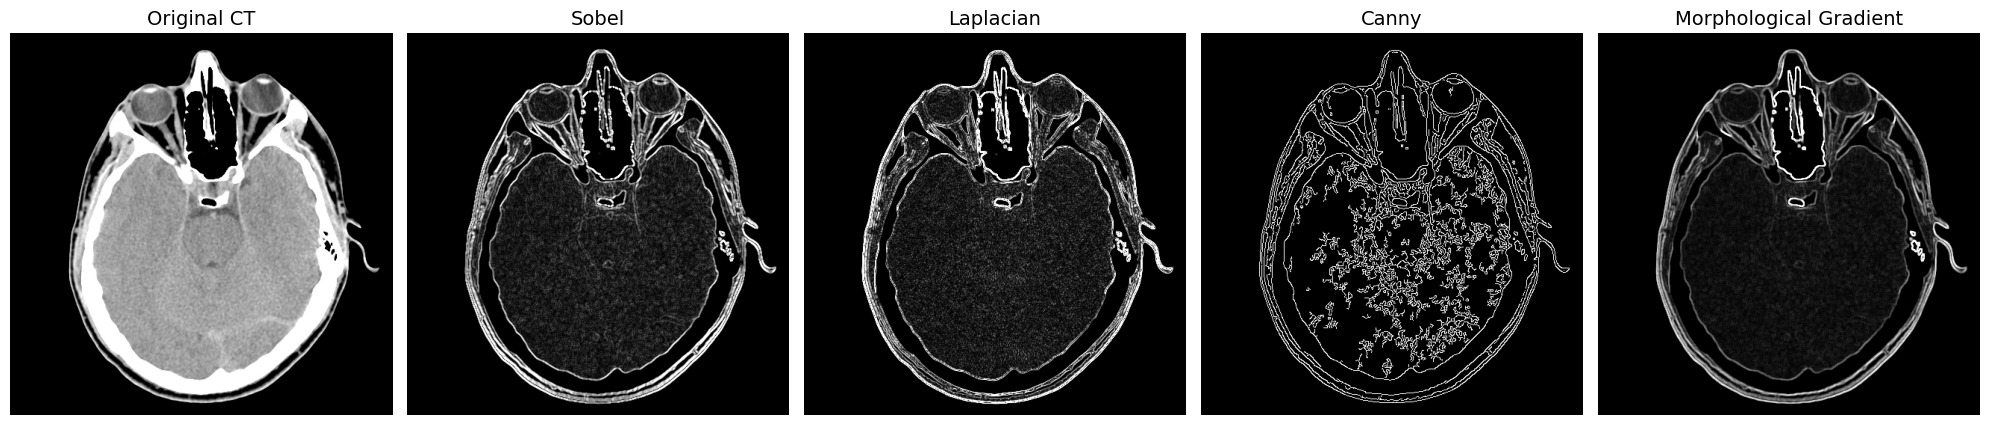

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests

# 1. 실험 영상 다운로드
url = "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0939(a)(headCT-Vandy).tif"
resp = requests.get(url)
image_array = np.asarray(bytearray(resp.content), dtype="uint8")
img = cv2.imdecode(image_array, cv2.IMREAD_GRAYSCALE)

# 2. 에지 검출 알고리즘 적용

# (1) Sobel 연산자 (1차 미분)
grad_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
grad_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
abs_grad_x = cv2.convertScaleAbs(grad_x)
abs_grad_y = cv2.convertScaleAbs(grad_y)
img_sobel = cv2.addWeighted(abs_grad_x, 0.5, abs_grad_y, 0.5, 0)

# (2) Laplacian 연산자 (2차 미분)
laplacian = cv2.Laplacian(img, cv2.CV_64F, ksize=3)
img_laplacian = cv2.convertScaleAbs(laplacian)

# (3) Canny 에지 검출기
img_canny = cv2.Canny(img, 50, 150)

# (4) Morphological Gradient (모폴로지 그래디언트)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
img_morph_grad = cv2.morphologyEx(img, cv2.MORPH_GRADIENT, kernel)


# 3. 결과 시각화
titles = ['Original CT', 'Sobel', 'Laplacian', 'Canny', 'Morphological Gradient']
images = [img, img_sobel, img_laplacian, img_canny, img_morph_grad]

plt.figure(figsize=(20, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i], fontsize=14)
    plt.axis('off')
plt.tight_layout()
plt.show()

#### HW#2-7 결과 분석

* **Sobel**
  * 윤곽선이 다소 굵고 부드럽게 추출됨.
  * 두개골이나 뇌의 굵직한 전체 뼈대 구조를 파악하는 데 유리하지만 미세한 경계선은 뭉뚱그려져 표현됨.

* **Laplacian**
  * 윤곽선이 매우 얇고 날카롭게 검출됨.
  * 단, 노이즈에 매우 민감하여 영상 내부의 자잘한 질감과 잡음까지 모두 경계로 인식해 결과가 다소 지저분하게 보임.

* **Canny**
  * 여러 최적화 단계를 거쳐 노이즈가 거의 없고 가장 얇고 선명한(1픽셀 두께) 단일 경계선을 추출함.
  * 불필요한 잡음을 억제하면서 주요 객체의 외곽선을 가장 깔끔하게 분리해 냄.

* **Morphological Gradient**
  * 에지가 끊기지 않고 일정한 두께를 가진 닫힌 형태(폐곡선)로 잘 나타남.
  * 선이 아주 얇지는 않지만, 객체의 테두리를 뚜렷하게 감싸는 느낌을 주어 영역 분할(Segmentation) 전처리에 매우 적합함.

# HW#2-8

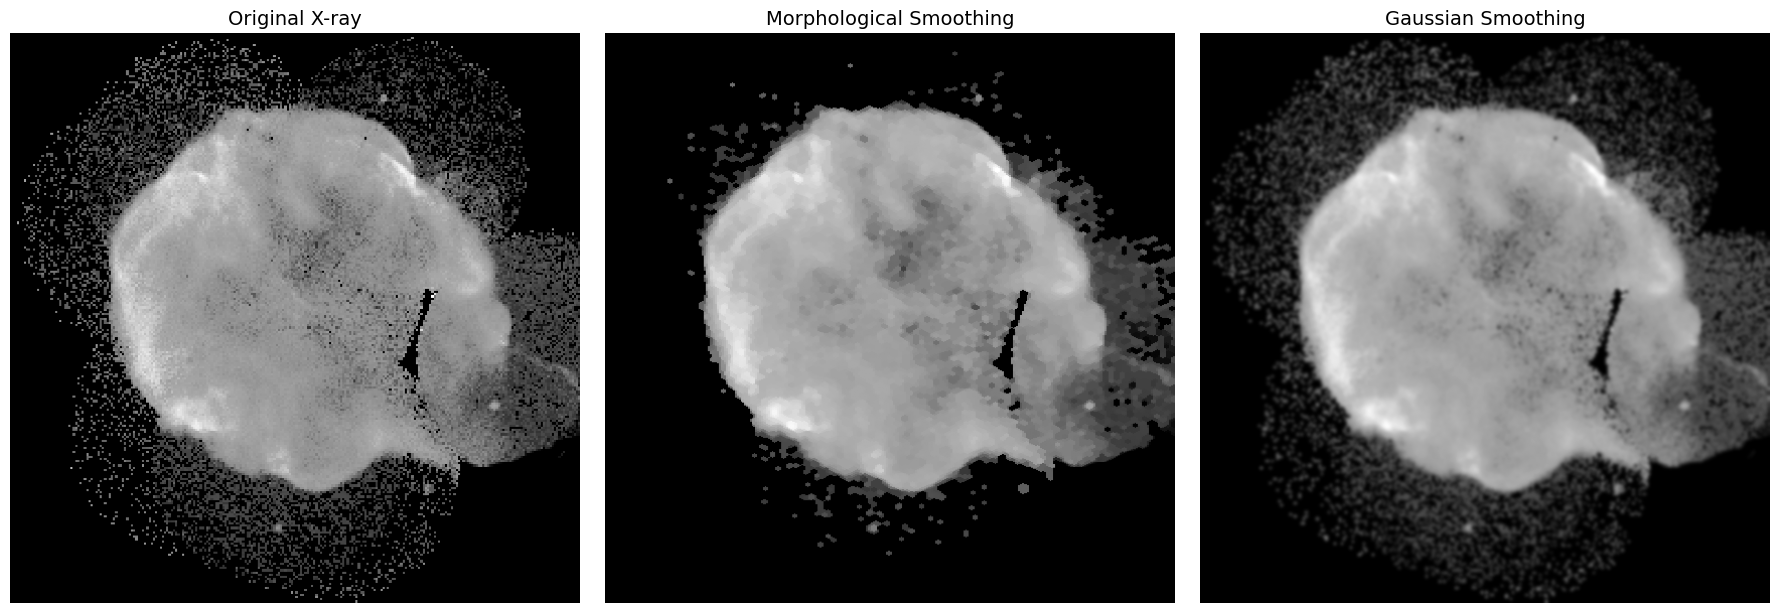

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests

# 1. 실험 영상 다운로드
url = "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0938(a)(cygnusloop_Xray_original).tif"
resp = requests.get(url)
image_array = np.asarray(bytearray(resp.content), dtype="uint8")
img = cv2.imdecode(image_array, cv2.IMREAD_GRAYSCALE)

# 2. 구조 요소 생성
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

# 3. 알고리즘 적용

# (1) Morphological Smoothing
# 열기(Opening)를 통해 배경의 밝은 노이즈를 먼저 제거
# 닫기(Closing)를 통해 객체 내부의 어두운 구멍을 메워줌
img_opened = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)
img_morph_smooth = cv2.morphologyEx(img_opened, cv2.MORPH_CLOSE, kernel)

# (2) 평활화 필터 (Smoothing Filter) - 가우시안 블러 사용
img_gaussian_smooth = cv2.GaussianBlur(img, (9, 9), 0)

# 4. 결과 시각화
titles = ['Original X-ray', 'Morphological Smoothing', 'Gaussian Smoothing']
images = [img, img_morph_smooth, img_gaussian_smooth]

plt.figure(figsize=(18, 6))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i], fontsize=14)
    plt.axis('off')
plt.tight_layout()
plt.show()

#### HW#2-8 결과 분석

* **Morphological Smoothing (형태학적 스무딩)**
  * 열기와 닫기 연산을 순차적으로 적용하여 배경에 흩뿌려진 밝은 점잡음(Salt noise)을 완벽하게 제거.
  * 노이즈는 효과적으로 지우면서도 타겟 객체(성운)의 원래 윤곽선(Edge)을 뭉개짐 없이 날카롭게 보존함.

* **Smoothing Filter (가우시안 평활화 필터)**
  * 주변 픽셀의 가중 평균을 구하는 블러링 방식으로 점잡음이 완전히 지워지지 않고 주변으로 뿌옇게 번짐(Smearing).
  * 노이즈뿐만 아니라 객체의 윤곽선까지 함께 뭉개져 영상 전체의 형태가 흐릿해지는 단점이 발생.

**결론**
배경의 무작위 점잡음을 제거하면서 객체의 경계선은 선명하게 유지해야 할 경우 일반적인 스무딩 필터보다 형태학적 스무딩이 훨씬 우수하고 적합한 결과물을 도출함.

# HW#2-9

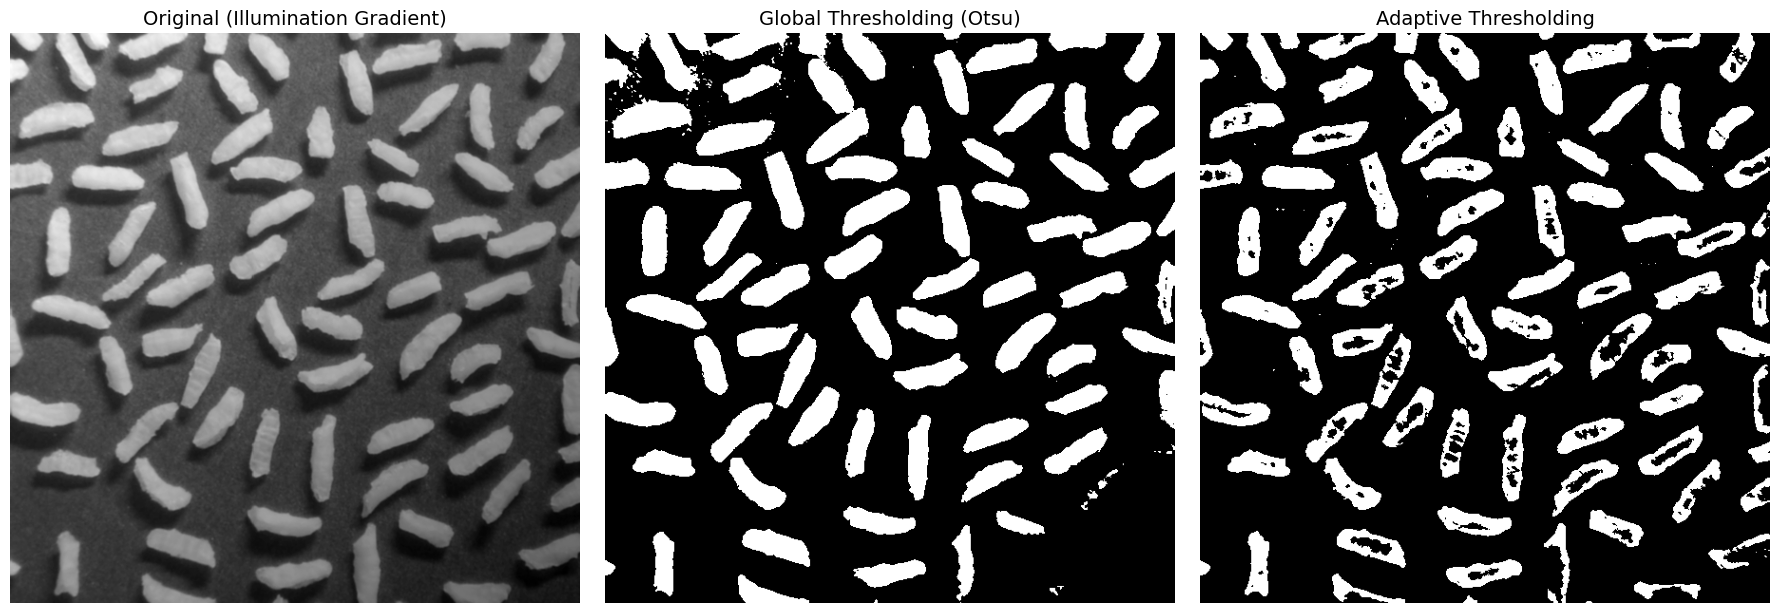

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests

# 1. 실험 영상 다운로드
url = "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0940(a)(rice_image_with_intensity_gradient).tif"
resp = requests.get(url)
image_array = np.asarray(bytearray(resp.content), dtype="uint8")
img = cv2.imdecode(image_array, cv2.IMREAD_GRAYSCALE)

# 2. 방법 1: 전역 이진화 (Global Thresholding - Otsu 알고리즘)
_, img_global = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 3. 방법 2: 적응형/지역 이진화 (Adaptive Thresholding)
block_size = 51
C_value = -15
img_adaptive = cv2.adaptiveThreshold(
    img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, block_size, C_value
)

# 4. 결과 시각화
titles = ['Original (Illumination Gradient)', 'Global Thresholding (Otsu)', 'Adaptive Thresholding']
images = [img, img_global, img_adaptive]

plt.figure(figsize=(18, 6))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i], fontsize=14)
    plt.axis('off')
plt.tight_layout()
plt.show()

#### HW#2-9 결과 분석

* **원본 영상 특성**: 영상 상단은 밝고 하단은 어두워 전체적인 밝기 차이가 심한 조명 불균일(Illumination Gradient) 상태
* **전역 이진화 (Global Thresholding)**: 영상 전체에 단일 임계값을 적용함. 조명 차이로 인해 하단의 어두운 쌀알들이 배경으로 잘못 인식되어 까맣게 묻히는 분할 실패가 발생
* **적응형 이진화 (Adaptive Thresholding)**: 각 픽셀 주변 영역(블록)의 평균 밝기를 기준으로 임계값을 지역적으로 다르게 설정함. 그라데이션 형태의 조명 변화를 극복하고 모든 영역에서 쌀알을 선명하게 분리해 냄.

**결론**
빛의 분포가 균일하지 않은 영상에서는 단일 기준을 사용하는 전역 이진화보다 국소적인 밝기 변화에 맞춰 기준이 유동적으로 변하는 적응형 이진화를 사용해야 정확한 객체 분할이 가능함.

# HW#2-10

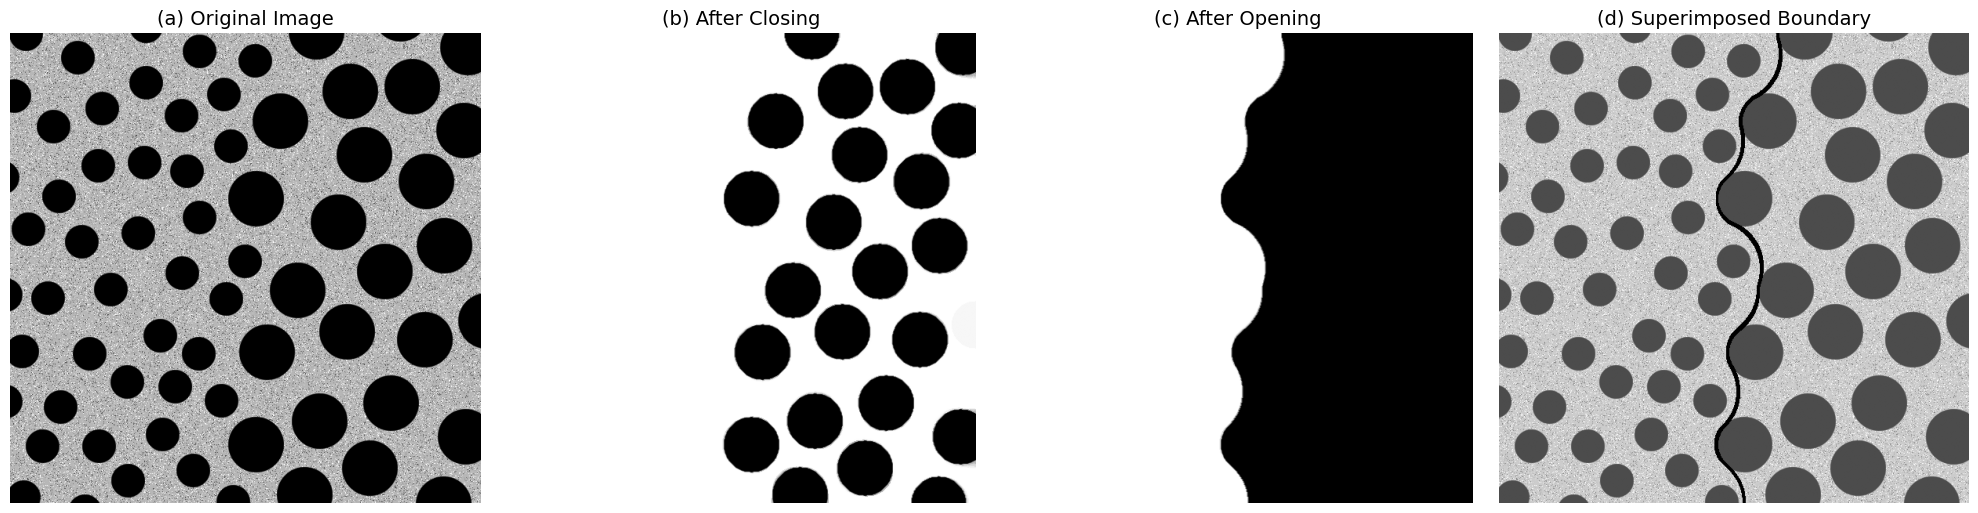

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests

# 1. 실험 영상 다운로드
url = "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0943(a)(dark_blobs_on_light_background).tif"
resp = requests.get(url)
image_array = np.asarray(bytearray(resp.content), dtype="uint8")
img = cv2.imdecode(image_array, cv2.IMREAD_GRAYSCALE)

# 2. 작은 블롭 제거 (Closing 연산)
kernel_small = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (61, 61))
img_closed = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel_small)

# 3. 큰 블롭 사이의 밝은 배경 제거 (Opening 연산)
kernel_large = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (121, 121))
img_opened = cv2.morphologyEx(img_closed, cv2.MORPH_OPEN, kernel_large)

# 4. 경계선 추출 (Morphological Gradient)
kernel_grad = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
img_grad = cv2.morphologyEx(img_opened, cv2.MORPH_GRADIENT, kernel_grad)

# 5. 원본 영상에 경계선 오버레이 (Superimpose)
img_result = img.copy()
img_result[img_grad > 0] = 0

# 6. 결과 시각화
titles = ['(a) Original Image', '(b) After Closing', '(c) After Opening', '(d) Superimposed Boundary']
images = [img, img_closed, img_opened, img_result]

plt.figure(figsize=(20, 5))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i], fontsize=14)
    plt.axis('off')
plt.tight_layout()
plt.show()

#### HW#2-10 결과 분석

* **(b) After Closing**: 작은 객체(Blob)들만 선택적으로 화면에서 지워지고 큰 객체들은 원래 형태가 보존됨.
* **(c) After Opening**: 남은 큰 객체들 사이의 밝은 틈새가 메워지면서 객체가 밀집된 영역 전체가 융합되어 하나의 거대한 덩어리로 분리됨.
* **(d) Superimposed Boundary**: 분할된 거대 덩어리의 윤곽선만 추출하여 원본에 덧씌움으로써 질감(객체의 밀도)이 다른 두 영역의 경계를 시각적으로 명확히 구분해 냄.

**결론**
구조 요소(커널)의 크기를 타겟 객체의 크기에 맞춰 다르게 설정하고 모폴로지 연산을 조합하면 객체의 크기와 밀집도(질감)를 기준으로 원하는 특정 영역만 정밀하게 분할할 수 있음.